In [1]:
import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from utils.basegenerators import Raw
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from utils.benchmark_metric import AUCMetric

from utils.basegenerators import BenchmarkGenerator,ReprosynGenerator, Raw
from reprosyn.methods import DS_PRIVBAYES
from utils.tapas.tapas_data_processors import AdultDataProcessor

In [11]:
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
target_record = data.get_records([0])
data.drop_records([0], in_place=True)
attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,1,2))

gen = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=10.0)

pipeline = BenchmarkPipeline(data, attack, [Raw(),gen], target_record=target_record)
benchmarking_metric = AUCMetric()


# just add the path to the folder where the generated data will be saved, the name of the file will be generated automatically
# pipeline.run([2,20], 1, 2,  plot_style='double', benchmarking_metric=benchmarking_metric)

# if you want to run the attack without generating data, just set generate=False and add the path to the folder where the generated data will be saved
# pipeline.run_importing_data([2,4], 1, 2, imported_data_path="data/shadow_datasets_Raw_4.pkl")

In [9]:
pipeline.ml_utility("income", optimize_hyperparams=False)

Evaluating original data
Evaluating : Raw
Evaluating generated data
Evaluating : PrivBayes_epsilon=1.0


KeyboardInterrupt: 

In [12]:
pipeline.average_dcr(100,metric="gower")

Evaluating : Raw
Evaluating : PrivBayes_epsilon=10.0


0.20973384

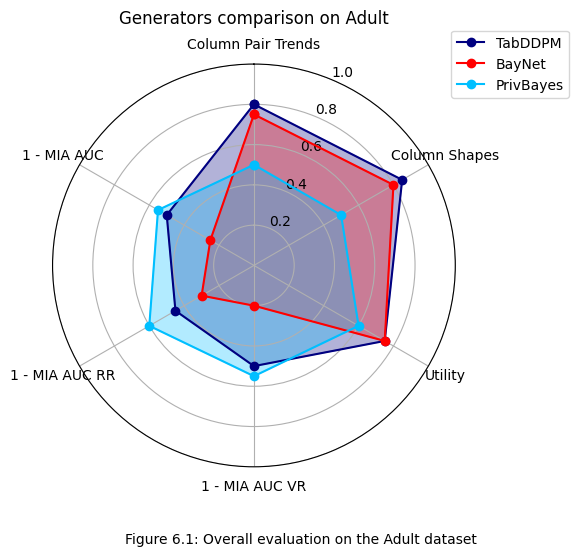

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Define the labels for each axis
labels = ['Column Pair Trends', 'Column Shapes', 'Utility', 
          '1 - MIA AUC VR', '1 - MIA AUC RR', '1 - MIA AUC']
num_vars = len(labels)

# Example data (scaled between 0 and 1)
tabddpm = [0.8, 0.85, 0.75, 0.5, 0.45, 0.5]
baynet = [0.75, 0.8, 0.75, 0.2, 0.3, 0.25]
privbayes = [0.5, 0.5, 0.6, 0.55, 0.6, 0.55]

# Function to close the loop for radar chart
def radar_data(data):
    return data + [data[0]]

tabddpm = radar_data(tabddpm)
baynet = radar_data(baynet)
privbayes = radar_data(privbayes)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the loop

# Initialize radar chart
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Plot each model
ax.plot(angles, tabddpm, label='TabDDPM', color='navy', marker='o')
ax.fill(angles, tabddpm, color='navy', alpha=0.3)

ax.plot(angles, baynet, label='BayNet', color='red', marker='o')
ax.fill(angles, baynet, color='red', alpha=0.3)

ax.plot(angles, privbayes, label='PrivBayes', color='deepskyblue', marker='o')
ax.fill(angles, privbayes, color='deepskyblue', alpha=0.3)

# Customize chart
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)  # Use original labels only
ax.set_ylim(0, 1)
ax.set_title('Generators comparison on Adult', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Caption
plt.figtext(0.5, 0.01, 'Figure 6.1: Overall evaluation on the Adult dataset', ha='center')

plt.tight_layout()
plt.show()

In [6]:
from typing import Literal
rank_range = [0, 0.17, 0.33, 0.5, 0.67, 0.83]
def compute_rank_from_metric(metric: float) -> float:
    idx = np.searchsorted(rank_range, metric, side='right') - 1
    print(idx)
    rank = 1 #chr(ord('A') + idx)
    return rank

In [7]:
compute_rank_from_metric(0.8)

4


1